In [11]:
import pandas as pd

# 1. Load your downloaded CSV file
# IMPORTANT: Change 'your_downloaded_file.csv' to the actual name of your file!
file_name = "bq-results-20260302-194305-1772480601839.csv"
print(f"Loading data from {file_name}...\n")
df = pd.read_csv(file_name)

Loading data from bq-results-20260302-194305-1772480601839.csv...



In [12]:
df.head()

,Event_Date,Initiator,Initiator_Country,Target,Total_Mentions,Unique_Outlets,Total_Articles,Article_Tone,Social_Media_Mentioned,All_Organizations_Found,Themes,News_URL
0,20240913,CHINA,CHN,UNITED STATES,44,1,44,-4.736842,NaN,"Sandy Hook Elementary School,4051;Justice Depa...","TAX_WORLDMAMMALS_HUMANS,1053;EPU_POLICY_WHITE_...",https://www.yahoo.com/news/forget-cats-eat-hum...
1,20240913,CHINA,CHN,UNITED STATES,44,1,44,-4.736842,NaN,"Sandy Hook Elementary School,4051;Justice Depa...","TAX_WORLDMAMMALS_HUMANS,1053;EPU_POLICY_WHITE_...",https://www.yahoo.com/news/forget-cats-eat-hum...
2,20241105,RUSSIA,RUS,PENNSYLVANIA,40,4,40,-5.792164,NaN,"Embassy Russian,1231;Microsoft,2668;Agency Sec...","TAX_FNCACT_ANALYSTS,2643;TAX_DISEASE_OBESE,800...",https://orainfo.net/agjencite-federale-thone-s...
3,20241106,RUSSIA,RUS,UNITED STATES,36,9,36,-4.708699,NaN,"Democratic National Committee,5717;Infrastruct...","WB_135_TRANSPORT,660;WB_135_TRANSPORT,803;WB_1...",https://www.irvinetimes.com/news/national/2470...
4,20240221,RUSSIAN,RUS,MARYLAND,30,6,30,-5.717054,NaN,"Associated Press,6259;Judiciary Committee,5986...","ECON_STOCKMARKET,1334;ARMEDCONFLICT,4853;TAX_F...",https://news.yahoo.com/ex-fbi-informant-charge...


In [13]:
# CLEANING THE DATA: remove duplicate rows
rows_before = len(df)
print(f"Number of rows before removing duplicates: {rows_before}")

df.drop_duplicates(inplace=True)

rows_after = len(df)
print(f"Number of rows after removing duplicates: {rows_after}")

Number of rows before removing duplicates: 6977
Number of rows after removing duplicates: 5302


In [14]:
df.head()

,Event_Date,Initiator,Initiator_Country,Target,Total_Mentions,Unique_Outlets,Total_Articles,Article_Tone,Social_Media_Mentioned,All_Organizations_Found,Themes,News_URL
0,20240913,CHINA,CHN,UNITED STATES,44,1,44,-4.736842,NaN,"Sandy Hook Elementary School,4051;Justice Depa...","TAX_WORLDMAMMALS_HUMANS,1053;EPU_POLICY_WHITE_...",https://www.yahoo.com/news/forget-cats-eat-hum...
2,20241105,RUSSIA,RUS,PENNSYLVANIA,40,4,40,-5.792164,NaN,"Embassy Russian,1231;Microsoft,2668;Agency Sec...","TAX_FNCACT_ANALYSTS,2643;TAX_DISEASE_OBESE,800...",https://orainfo.net/agjencite-federale-thone-s...
3,20241106,RUSSIA,RUS,UNITED STATES,36,9,36,-4.708699,NaN,"Democratic National Committee,5717;Infrastruct...","WB_135_TRANSPORT,660;WB_135_TRANSPORT,803;WB_1...",https://www.irvinetimes.com/news/national/2470...
4,20240221,RUSSIAN,RUS,MARYLAND,30,6,30,-5.717054,NaN,"Associated Press,6259;Judiciary Committee,5986...","ECON_STOCKMARKET,1334;ARMEDCONFLICT,4853;TAX_F...",https://news.yahoo.com/ex-fbi-informant-charge...
5,20240423,CHINESE,CHN,AMERICAN,30,3,30,-3.169399,"Instagram,","Instagram,4948;Microsoft,3460;Google,3469;Goog...","ELECTION,1207;WB_1921_PRIVATE_SECTOR_DEVELOPME...",https://www.kazu.org/npr-news/2024-04-22/tikto...


In [17]:
df.groupby(['Event_Date', 'Initiator_Country'])['Event_Date'].value_counts()

Event_Date  Initiator_Country
20240101    CHN                  4
20240102    CHN                  7
            RUS                  3
20240103    CHN                  5
20240104    CHN                  2
                                ..
20241229    IRN                  2
20241230    IRN                  2
            RUS                  4
20241231    CHN                  2
            RUS                  4
Name: count, Length: 827, dtype: int64

In [18]:
# Save counts and marks for each country, order by day
df['Date'] = pd.to_datetime(df['Event_Date'].astype(str), format='%Y%m%d', errors='coerce')
daily_counts = df.groupby(['Date', 'Initiator_Country'])['Date'].value_counts().reset_index(name='News')
daily_counts = daily_counts.sort_values('Date')

daily_marks = df.groupby(['Date', 'Initiator_Country'])['Total_Mentions'].sum().reset_index()
daily_marks = daily_marks.sort_values('Date')

# Concat
daily_data = pd.merge(daily_counts, daily_marks, on=['Date', 'Initiator_Country'], how='left')
daily_data.head()

,Date,Initiator_Country,News,Total_Mentions
0,2024-01-01,CHN,4,15
1,2024-01-02,CHN,7,33
2,2024-01-02,RUS,3,13
3,2024-01-03,CHN,5,28
4,2024-01-04,CHN,2,7


In [38]:
daily_data.to_csv('daily_news_data.csv', index=False)

In [19]:
# Select RUS, fill missing dates with RUS and 0 mentions. Include all dates.
rus_data = daily_data[daily_data['Initiator_Country'] == 'RUS']
rus_data = rus_data.set_index('Date').resample('D').asfreq().fillna({'Initiator_Country': 'RUS', 'News': 0, 'Total_Mentions': 0}).reset_index()
rus_data.head()
rus_data.to_csv("rus_daily_data.csv", index=False)

In [20]:
rus_data

,Date,Initiator_Country,News,Total_Mentions
0,2024-01-02,RUS,3.0,13.0
1,2024-01-03,RUS,0.0,0.0
2,2024-01-04,RUS,0.0,0.0
3,2024-01-05,RUS,0.0,0.0
4,2024-01-06,RUS,2.0,8.0
...,...,...,...,...
360,2024-12-27,RUS,2.0,6.0
361,2024-12-28,RUS,1.0,2.0
362,2024-12-29,RUS,0.0,0.0
363,2024-12-30,RUS,4.0,9.0


In [21]:
# 2. Who is generating the most noise? (Impact by Country)
# This groups the data by Russia (RUS), Iran (IRN), and China (CHN) 
# and adds up their total global mentions.
country_impact = df.groupby('Initiator_Country')[['Total_Mentions', 'Unique_Outlets']].sum()
country_impact = country_impact.sort_values(by='Total_Mentions', ascending=False)

print("--- IMPACT BY ACTOR (TOTAL MENTIONS) ---")
print(country_impact)
print("\n" + "="*40 + "\n")

--- IMPACT BY ACTOR (TOTAL MENTIONS) ---
                   Total_Mentions  Unique_Outlets
Initiator_Country                                
RUS                          8080            2497
CHN                          7698            2057
IRN                          3628            1046




In [22]:
# 3. Clean, Filter, and Count the GKG Themes
top_themes = (
    df['Themes']
    .dropna()
    .str.replace(';', ',') 
    .str.split(',')
    .explode()
    .str.strip()
)
# Remove empty strings
top_themes = top_themes[top_themes != '']

# --- THE NEW FILTERING STEP ---
# This looks for any theme containing these taxonomy prefixes.
# The "~" symbol tells pandas to KEEP everything that DOES NOT match.
noise_patterns = 'TAX_WORLDLANGUAGES_|TAX_ETHNICITY_|USPEC_POLITICS_GENERAL1'
top_themes = top_themes[~top_themes.str.contains(noise_patterns, na=False)]

# Create a clean dataframe of the top 50 themes
themes_df = top_themes.value_counts().head(50).reset_index()
themes_df.columns = ['Theme', 'Count']

print("--- TOP 20 MOST FREQUENT THEMES (CLEANED) ---")
print(themes_df.head(20))
print("\n" + "="*40 + "\n")

--- TOP 20 MOST FREQUENT THEMES (CLEANED) ---
                                                Theme  Count
0                                TAX_FNCACT_PRESIDENT  19350
1                                              LEADER  19208
2                                            ELECTION  15199
3                          EPU_CATS_NATIONAL_SECURITY  14374
4                                  GENERAL_GOVERNMENT  12505
5                                CRISISLEX_C07_SAFETY  12309
6                                       ARMEDCONFLICT  12078
7                               EPU_POLICY_GOVERNMENT  11822
8   WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES  10030
9                           WB_678_DIGITAL_GOVERNMENT   9797
10                         WB_694_BROADCAST_AND_MEDIA   8935
11            WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE   8829
12                               EPU_POLICY_POLITICAL   8475
13                               TAX_FNCACT_OFFICIALS   8283
14                             CRISISLE

In [23]:
# 4. Clean and Count the Organizations (Beyond Social Media)
# Let's see which companies, agencies, or groups were mentioned the most
top_orgs = (
    df['All_Organizations_Found']
    .dropna()
    .str.replace(';', ',')
    .str.split(',')
    .explode()
    .str.strip()
)
top_orgs = top_orgs[top_orgs != '']

print("--- TOP 20 MOST FREQUENT ORGANIZATIONS ---")
print(top_orgs.value_counts().head(20))

--- TOP 20 MOST FREQUENT ORGANIZATIONS ---
All_Organizations_Found
United States                     18988
White House                        3011
Cnn                                1820
Microsoft                          1436
Reuters                            1263
Justice Department                 1025
Chinese Communist Party             957
Twitter                             786
New York Times                      703
Facebook                            695
Xinhua                              587
Google                              585
United Nations                      583
National Intelligence               566
European Union                      547
Youtube                             452
Associated Press                    442
Democratic Party                    412
Infrastructure Security Agency      359
Security Council                    333
Name: count, dtype: int64



Plot successfully generated and saved as: Interference_Timeline_2024.png


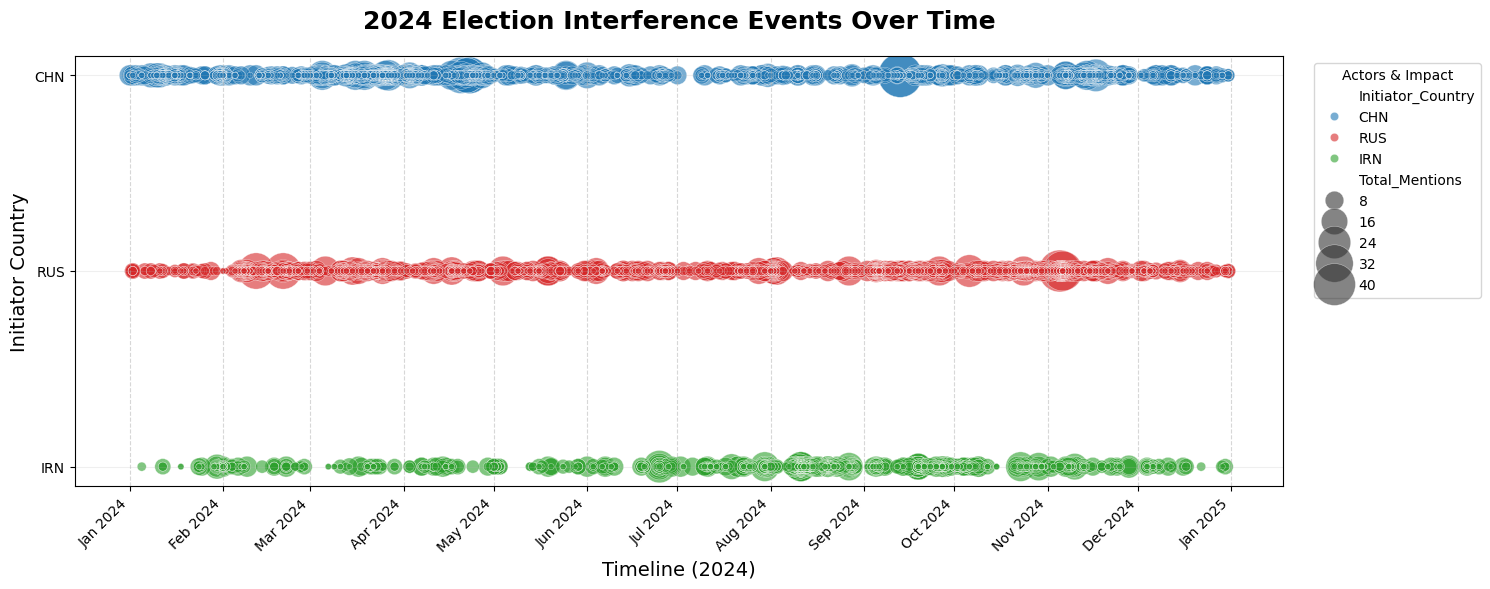

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Load the data (if you haven't already in the main script)
file_name = "bq-results-20260302-194305-1772480601839.csv" # Ensure this matches your file
df = pd.read_csv(file_name)

# 2. Convert the GDELT integer date (YYYYMMDD) into a proper Date object for plotting
df['Date'] = pd.to_datetime(df['Event_Date'].astype(str), format='%Y%m%d', errors='coerce')

# 3. Set up the figure size (wide and horizontal)
plt.figure(figsize=(15, 6))

# 4. Create the scatter plot
# 'x' is time, 'y' is the actor, and 'size' is the impact score
sns.scatterplot(
    data=df, 
    x='Date', 
    y='Initiator_Country', 
    size='Total_Mentions',   # Bubble size depends on the news impact
    sizes=(20, 1000),        # Minimum and Maximum bubble size
    alpha=0.6,               # Make bubbles slightly transparent so overlaps are visible
    hue='Initiator_Country', # Color-code by country
    palette={'RUS': '#d62728', 'IRN': '#2ca02c', 'CHN': '#1f77b4'} # Red, Green, Blue
)

# 5. Format the aesthetics
plt.title('2024 Election Interference Events Over Time', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Timeline (2024)', fontsize=14)
plt.ylabel('Initiator Country', fontsize=14)

# Format the X-axis to show clean month names (e.g., "Jan 2024", "Feb 2024")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')

# Add subtle grid lines for readability
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.grid(True, axis='y', linestyle='-', alpha=0.2)

# Move the legend outside the plot so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Actors & Impact')

# 6. Save the plot as a high-resolution image
plt.tight_layout()
output_image = 'Interference_Timeline_2024.png'
plt.savefig(output_image, dpi=300)

print(f"\nPlot successfully generated and saved as: {output_image}")

In [43]:
daily_df = df.groupby([pd.Grouper(key='Date', freq='D'), 'Initiator_Country'])['Date'].value_counts().reset_index()
daily_df

,Date,Initiator_Country,count
0,2024-01-01,CHN,6
1,2024-01-02,CHN,8
2,2024-01-02,RUS,7
3,2024-01-03,CHN,6
4,2024-01-04,CHN,3
...,...,...,...
822,2024-12-29,IRN,2
823,2024-12-30,IRN,3
824,2024-12-30,RUS,7
825,2024-12-31,CHN,6


In [46]:
daily_df = df.groupby([pd.Grouper(key='Date', freq='D'), 'Initiator_Country'])['Date'].value_counts().reset_index()
daily_df.rename(columns={'count': 'News'}, inplace=True)
daily_df

,Date,Initiator_Country,News
0,2024-01-01,CHN,6
1,2024-01-02,CHN,8
2,2024-01-02,RUS,7
3,2024-01-03,CHN,6
4,2024-01-04,CHN,3
...,...,...,...
822,2024-12-29,IRN,2
823,2024-12-30,IRN,3
824,2024-12-30,RUS,7
825,2024-12-31,CHN,6


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Load data and setup dates (if not already done)
file_name = "bq-results-20260302-194305-1772480601839.csv" # Ensure this matches your file
df = pd.read_csv(file_name)
df['Date'] = pd.to_datetime(df['Event_Date'].astype(str), format='%Y%m%d', errors='coerce')

# 2. Smooth the data: Aggregate total mentions by WEEK ('W') and Country
daily_df = df.groupby([pd.Grouper(key='Date', freq='D'), 'Initiator_Country'])['Date'].value_counts().reset_index()
daily_df.rename(columns={'count': 'News'}, inplace=True)

# Set up our consistent colors
colors = {'RUS': '#d62728', 'IRN': '#2ca02c', 'CHN': '#1f77b4'}

# =========================================================
# PLOT 1: ALL COUNTRIES ON THE SAME AXIS
# =========================================================
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=daily_df, 
    x='Date', 
    y='News', 
    hue='Initiator_Country',
    palette=colors,
    linewidth=2.5,  # Make lines thicker
    marker='o',     # Add a dot for each week
    markersize=6
)

plt.title('Daily Election Interference News (Combined Axis)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date (2024)', fontsize=14)
plt.ylabel('Total News News (Daily)', fontsize=14)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Actor', loc='upper right')

plt.tight_layout()
output_1 = 'Line_Chart_Combined_2024.png'
plt.savefig(output_1, dpi=300)
print(f"Combined line chart saved as: {output_1}")
plt.close() # Close to start the next plot fresh


# =========================================================
# PLOT 2: SEPARATED "LANES" (SUBPLOTS)
# =========================================================
# Create 3 rows and 1 column of charts, sharing the same X-axis
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

country_names = {'RUS': 'Russia', 'IRN': 'Iran', 'CHN': 'China'}

# Loop through our three countries and plot them on their own axis
for i, country in enumerate(['RUS', 'IRN', 'CHN']):
    # Filter the data for just this country
    country_data = daily_df[daily_df['Initiator_Country'] == country]
    
    sns.lineplot(
        data=country_data,
        x='Date',
        y='News',
        color=colors[country],
        ax=axes[i],
        linewidth=2.5,
        marker='o',
        markersize=6
    )
    
    # Format each individual subplot
    axes[i].set_title(f'{country_names[country]} Activity', fontsize=14, fontweight='bold', color=colors[country])
    axes[i].set_ylabel('Daily News', fontsize=12)
    axes[i].set_ylim(0, daily_df['News'].max() * 1.05)  # Set a consistent Y-axis limit for better comparison
    axes[i].grid(True, linestyle='--', alpha=0.5)
    
    # Remove the redundant x-axis label for the top two plots
    if i < 2:
        axes[i].set_xlabel('')

# Format the bottom X-axis
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].set_xlabel('Timeline (2024)', fontsize=14)

plt.suptitle('Daily Election Interference News (Separated by Actor)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

output_2 = 'Line_Chart_Separated_2024.png'
plt.savefig(output_2, dpi=300)
print(f"Separated line chart saved as: {output_2}")
plt.close()

Combined line chart saved as: Line_Chart_Combined_2024.png
Separated line chart saved as: Line_Chart_Separated_2024.png


Intent Heatmap saved as: Intent_Heatmap_2024.png


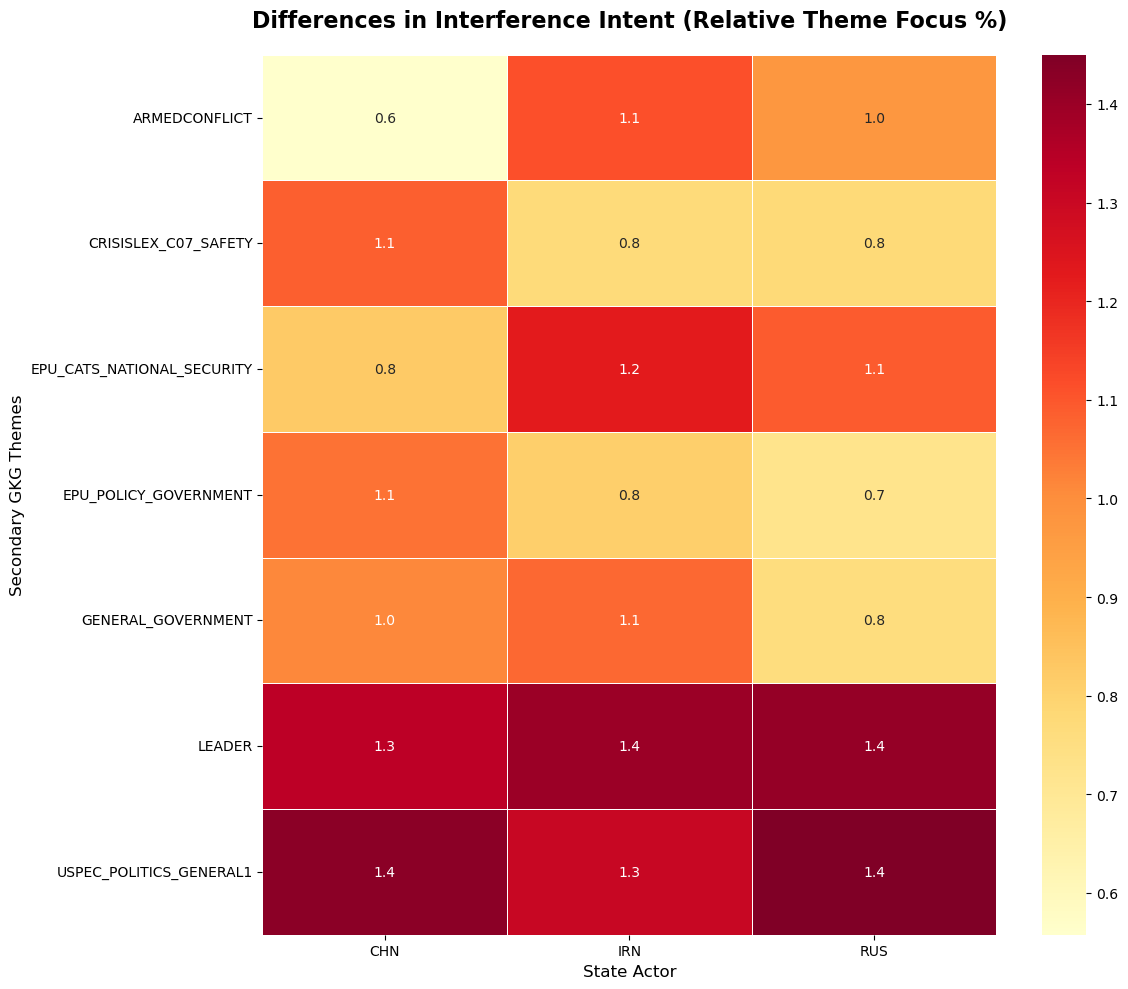

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
file_name = "bq-results-20260302-194305-1772480601839.csv" # Ensure this matches your file
df = pd.read_csv(file_name)

# 2. Explode the Themes but KEEP the Country attached
# We create a new dataframe where every single theme gets its own row next to the country that initiated it
themes_expanded = df[['Initiator_Country', 'Themes']].dropna()
themes_expanded['Themes'] = themes_expanded['Themes'].str.replace(';', ',').str.split(',')
themes_expanded = themes_expanded.explode('Themes')
themes_expanded['Themes'] = themes_expanded['Themes'].str.strip()
themes_expanded = themes_expanded[themes_expanded['Themes'] != '']

# 3. Filter out the noise AND the "obvious" query terms
# We remove the search terms so we can see the hidden secondary intent
noise_and_obvious = 'TAX_|ELECTION|CYBER|DISINFORMATION|PROPAGANDA|HACK'
filtered_themes = themes_expanded[~themes_expanded['Themes'].str.contains(noise_and_obvious, na=False, case=False)]

# 4. Calculate the Relative Proportion (Percentage) per Country
# Count how many times each theme appears for each country
theme_counts = filtered_themes.groupby(['Initiator_Country', 'Themes']).size().reset_index(name='Count')

# Calculate the total number of themes generated by EACH country separately
total_per_country = theme_counts.groupby('Initiator_Country')['Count'].transform('sum')

# Divide the specific theme count by the country's total to get the percentage!
theme_counts['Percentage'] = (theme_counts['Count'] / total_per_country) * 100

# 5. Find the Top Defining Themes
# To make the chart readable, let's only look at themes that account for at least 1% of a country's focus
top_themes_list = theme_counts[theme_counts['Percentage'] >= 1.0]['Themes'].unique()
final_data = theme_counts[theme_counts['Themes'].isin(top_themes_list)]

# Pivot the data so Countries are columns, Themes are rows, and Percentages are the values
pivot_df = final_data.pivot(index='Themes', columns='Initiator_Country', values='Percentage').fillna(0)

# 6. Generate the Comparative Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    pivot_df, 
    cmap='YlOrRd', # Yellow to Orange to Red color scale
    annot=True,    # Show the actual percentage numbers in the boxes
    fmt=".1f",     # Format numbers to 1 decimal place
    linewidths=.5
)

plt.title('Differences in Interference Intent (Relative Theme Focus %)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Secondary GKG Themes', fontsize=12)
plt.xlabel('State Actor', fontsize=12)
plt.tight_layout()

output_heatmap = 'Intent_Heatmap_2024.png'
plt.savefig(output_heatmap, dpi=300)
print(f"Intent Heatmap saved as: {output_heatmap}")

Comparison chart successfully generated: Tactic_Comparison_2024.png


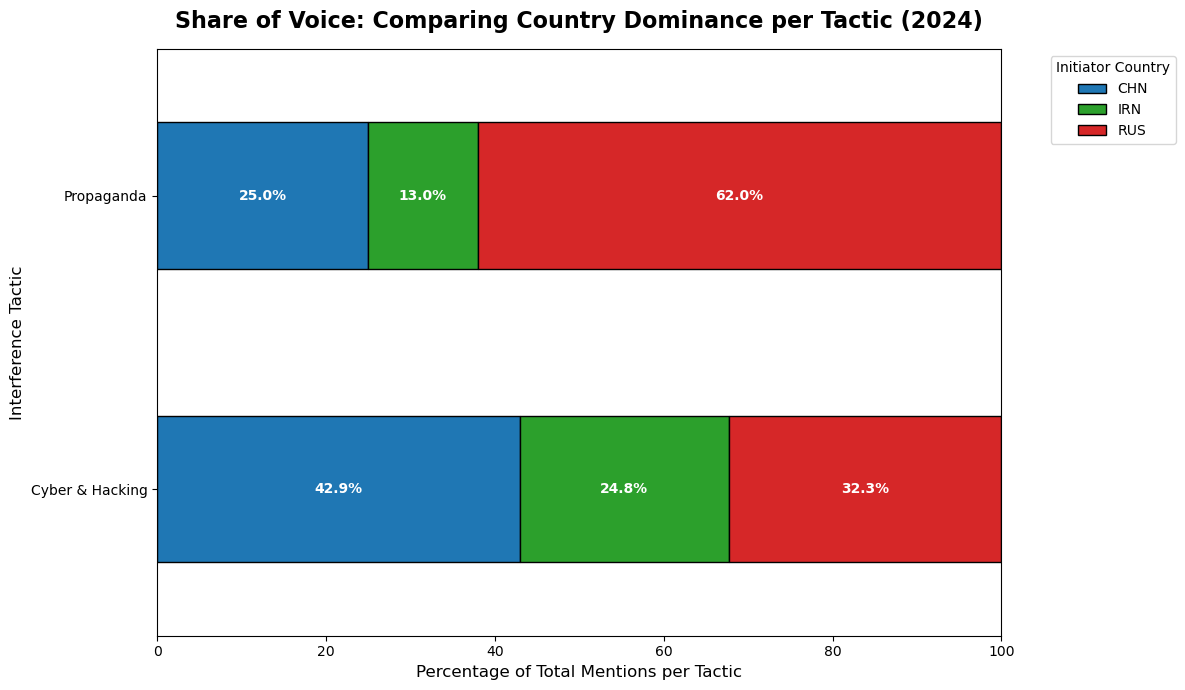

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
file_name = "bq-results-20260302-194305-1772480601839.csv" # Ensure this matches your file name
df = pd.read_csv(file_name)

# 2. Explode the Themes
themes_expanded = df[['Initiator_Country', 'Themes']].dropna()
themes_expanded['Themes'] = themes_expanded['Themes'].str.replace(';', ',').str.split(',')
themes_expanded = themes_expanded.explode('Themes')
themes_expanded['Themes'] = themes_expanded['Themes'].str.strip().str.upper()

# 3. Categorize into your exact final SQL Buckets
def map_final_tactics(theme):
    if 'CYBERATTACK' in theme or 'CYBER' in theme:
        return 'Cyber & Hacking'
    elif 'SPAMOUFLAGE' in theme:
        return 'Spamouflage'
    elif 'DISINFORMATION' in theme:
        return 'Disinformation'
    elif 'PROPAGANDA' in theme:
        return 'Propaganda'
    elif 'INTERFERE' in theme:
        return 'General Interference'
    else:
        return None # Drop background noise

themes_expanded['Tactic'] = themes_expanded['Themes'].apply(map_final_tactics)
core_df = themes_expanded.dropna(subset=['Tactic'])

# 4. Count the occurrences: How many times did each country use each tactic?
tactic_counts = core_df.groupby(['Tactic', 'Initiator_Country']).size().reset_index(name='Count')

# 5. Calculate "Share of Voice" (Percentage per Tactic)
# We calculate the total count FOR EACH TACTIC, then divide the country's count by that total
total_per_tactic = tactic_counts.groupby('Tactic')['Count'].transform('sum')
tactic_counts['Share_of_Voice'] = (tactic_counts['Count'] / total_per_tactic) * 100

# Pivot the data for a 100% Stacked Bar Chart
pivot_df = tactic_counts.pivot(index='Tactic', columns='Initiator_Country', values='Share_of_Voice').fillna(0)

# Sort the tactics by the total raw volume so the biggest categories are at the top
tactic_totals = core_df.groupby('Tactic').size().sort_values(ascending=False).index
pivot_df = pivot_df.reindex(tactic_totals)

# 6. Plot the Comparative 100% Stacked Bar Chart
colors = {'RUS': '#d62728', 'IRN': '#2ca02c', 'CHN': '#1f77b4'} # Red, Green, Blue

# Create a horizontal stacked bar chart
ax = pivot_df.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 7), 
    color=[colors.get(x, '#333333') for x in pivot_df.columns],
    edgecolor='black'
)

# Formatting the chart
plt.title('Share of Voice: Comparing Country Dominance per Tactic (2024)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Total Mentions per Tactic', fontsize=12)
plt.ylabel('Interference Tactic', fontsize=12)

# Ensure X-axis goes from 0 to 100%
plt.xlim(0, 100)

# Move the legend
plt.legend(title='Initiator Country', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add the percentage labels inside the bars
for p in ax.patches:
    width = p.get_width()
    if width > 3: # Only add text if the bar section is wide enough to fit it
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f'{width:.1f}%', (x, y), ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()

# Save the plot
output_chart = 'Tactic_Comparison_2024.png'
plt.savefig(output_chart, dpi=300)
print(f"Comparison chart successfully generated: {output_chart}")

In [30]:
import pandas as pd

# 1. Load the data
file_name = "bq-results-20260302-194305-1772480601839.csv"  # Ensure this matches your file name
df = pd.read_csv(file_name)

# 2. Define our Tactical Buckets based on your SQL
tactics_dict = {
    'Cyber & Hacking': ['CYBER', 'HACK', 'CYBERATTACK'],
    'Spamouflage': ['SPAMOUFLAGE'],
    'Disinformation': ['DISINFORMATION'],
    'Propaganda': ['PROPAGANDA'],
    'General Interference': ['INTERFERE']
}

# 3. Define the "Noise" we want to exclude from the results
# We exclude TAX_ items, and we exclude the names of the tactics themselves 
# so we can see the *actual* context of the story.
noise_keywords = ['TAX_', 'ELECTION', 'CYBER', 'HACK', 'SPAMOUFLAGE', 
                  'DISINFORMATION', 'PROPAGANDA', 'INTERFERE']

co_occurrences = []

# 4. Scan every single article (row) in the dataset
print("Scanning articles for co-occurring themes...\n")
for index, row in df.iterrows():
    country = row['Initiator_Country']
    
    # Clean the themes for this specific article
    themes_raw = str(row['Themes']).upper().replace(';', ',').split(',')
    themes = [t.strip() for t in themes_raw if t.strip() != '']
    
    # Check which primary tactics are present in this article
    present_tactics = []
    for tactic_name, keywords in tactics_dict.items():
        if any(any(k in t for k in keywords) for t in themes):
            present_tactics.append(tactic_name)
            
    # If no primary tactic was found (just generic election news), skip it
    if not present_tactics:
        continue
        
    # Extract the SECONDARY themes (filtering out the noise)
    secondary_themes = [
        t for t in themes 
        if not any(noise in t for noise in noise_keywords)
    ]
    
    # Record every time a secondary theme appears alongside a primary tactic
    for tactic in present_tactics:
        for sec_theme in secondary_themes:
            co_occurrences.append({
                'Country': country,
                'Primary_Tactic': tactic,
                'Secondary_Theme': sec_theme
            })

# 5. Convert to a DataFrame and count everything up
co_df = pd.DataFrame(co_occurrences)

# Group by Country and Tactic, then count the secondary themes
results = co_df.groupby(['Country', 'Primary_Tactic', 'Secondary_Theme']).size().reset_index(name='Count')

# Sort to get the most frequent ones at the top
results = results.sort_values(by=['Country', 'Primary_Tactic', 'Count'], ascending=[True, True, False])

# 6. Print the Top 5 Co-occurring themes for each Country + Tactic combination
countries = ['RUS', 'IRN', 'CHN']

for country in countries:
    print(f"{"="*50}")
    print(f" TARGET ACTOR: {country} ")
    print(f"{"="*50}")
    
    country_data = results[results['Country'] == country]
    
    for tactic in tactics_dict.keys():
        tactic_data = country_data[country_data['Primary_Tactic'] == tactic]
        
        # Only print if they actually used this tactic
        if not tactic_data.empty:
            print(f"\n>> When deploying [ {tactic.upper()} ], they focus on:")
            # Grab the top 5
            top_5 = tactic_data.head(5)
            for _, row in top_5.iterrows():
                print(f"   - {row['Secondary_Theme']} (Found in {row['Count']} articles)")
                
print("\nAnalysis complete!")

Scanning articles for co-occurring themes...

 TARGET ACTOR: RUS 

>> When deploying [ CYBER & HACKING ], they focus on:
   - USPEC_POLITICS_GENERAL1 (Found in 6024 articles)
   - LEADER (Found in 5725 articles)
   - CRISISLEX_C07_SAFETY (Found in 3823 articles)
   - EPU_CATS_NATIONAL_SECURITY (Found in 3772 articles)
   - EPU_POLICY_GOVERNMENT (Found in 3249 articles)

>> When deploying [ PROPAGANDA ], they focus on:
   - EPU_CATS_NATIONAL_SECURITY (Found in 6616 articles)
   - USPEC_POLITICS_GENERAL1 (Found in 6495 articles)
   - ARMEDCONFLICT (Found in 6122 articles)
   - LEADER (Found in 6050 articles)
   - WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES (Found in 4581 articles)
 TARGET ACTOR: IRN 

>> When deploying [ CYBER & HACKING ], they focus on:
   - LEADER (Found in 2746 articles)
   - USPEC_POLITICS_GENERAL1 (Found in 2556 articles)
   - GENERAL_GOVERNMENT (Found in 1602 articles)
   - CRISISLEX_C07_SAFETY (Found in 1511 articles)
   - EPU_CATS_NATIONAL_SECURITY (Found i

In [31]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load the data
file_name = "bq-results-20260302-194305-1772480601839.csv"  # Ensure this matches your file name
df = pd.read_csv(file_name)

# 2. Clean and prep the themes
# We need to drop empty rows and filter out the taxonomy noise (TAX_) 
# as well as the obvious search terms so we get the underlying intent.
noise_patterns = 'TAX_|ELECTION|CYBER|DISINFORMATION|PROPAGANDA|HACK|SPAMOUFLAGE|INTERFERE'

# Explode the themes so we can filter them individually
themes_expanded = df[['Initiator_Country', 'Themes']].dropna()
themes_expanded['Themes'] = themes_expanded['Themes'].str.replace(';', ',').str.split(',')
themes_expanded = themes_expanded.explode('Themes')
themes_expanded['Themes'] = themes_expanded['Themes'].str.strip().str.upper()

# Drop the noise and empty rows
filtered_themes = themes_expanded[~themes_expanded['Themes'].str.contains(noise_patterns, na=False)]
filtered_themes = filtered_themes[filtered_themes['Themes'] != '']

# 3. Build the "Corpus" (One massive document per country)
# We group by country and join all their remaining themes into a single giant string separated by spaces.
# Because GDELT themes use underscores instead of spaces (e.g., ELECTION_FRAUD), this works perfectly for TF-IDF tokenization.
corpus_df = filtered_themes.groupby('Initiator_Country')['Themes'].apply(lambda x: ' '.join(x)).reset_index()

# 4. Run the TF-IDF Algorithm
# We initialize the vectorizer to look at individual themes (words)
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus_df['Themes'])

# Extract the theme names (feature names)
feature_names = vectorizer.get_feature_names_out()

# Create a clean DataFrame of the TF-IDF scores
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=corpus_df['Initiator_Country'])

# 5. Extract and Print the Top Unique Themes per Country
print("\n" + "="*60)
print(" TF-IDF ANALYSIS: UNIQUE TACTICAL FINGERPRINTS")
print("="*60)

# Loop through each country and print the themes with the highest TF-IDF scores
for country in tfidf_df.index:
    print(f"\n[{country}] Defining Characteristics (Highest TF-IDF Scores):")
    
    # Sort the scores for this specific country in descending order
    top_features = tfidf_df.loc[country].sort_values(ascending=False).head(10)
    
    for theme, score in top_features.items():
        # Print the theme and its TF-IDF weight
        print(f"  - {theme.upper()}: {score:.4f}")

print("\nAnalysis complete!")


 TF-IDF ANALYSIS: UNIQUE TACTICAL FINGERPRINTS

[CHN] Defining Characteristics (Highest TF-IDF Scores):
  - USPEC_POLITICS_GENERAL1: 0.3563
  - LEADER: 0.3338
  - CRISISLEX_C07_SAFETY: 0.2709
  - EPU_POLICY_GOVERNMENT: 0.2626
  - GENERAL_GOVERNMENT: 0.2530
  - EPU_CATS_NATIONAL_SECURITY: 0.2060
  - WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE: 0.1839
  - USPEC_POLICY1: 0.1684
  - WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES: 0.1589
  - WB_678_DIGITAL_GOVERNMENT: 0.1526

[IRN] Defining Characteristics (Highest TF-IDF Scores):
  - LEADER: 0.3465
  - USPEC_POLITICS_GENERAL1: 0.3243
  - EPU_CATS_NATIONAL_SECURITY: 0.3035
  - ARMEDCONFLICT: 0.2755
  - GENERAL_GOVERNMENT: 0.2643
  - CRISISLEX_CRISISLEXREC: 0.2393
  - EPU_POLICY_GOVERNMENT: 0.2009
  - CRISISLEX_C07_SAFETY: 0.1915
  - WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE: 0.1608
  - EPU_POLICY_POLITICAL: 0.1440

[RUS] Defining Characteristics (Highest TF-IDF Scores):
  - USPEC_POLITICS_GENERAL1: 0.3726
  - LEADER: 0.3619
  - EPU_CATS_NATIO

In [32]:
import pandas as pd

# 1. Load your downloaded data
file_name = "bq-results-20260302-194305-1772480601839.csv"  # Ensure this matches your file name
df = pd.read_csv(file_name)

# 2. Define our Party Keywords
# We use lists of keywords to catch the different ways journalists refer to the parties
democrat_keywords = ['DEMOCRAT', 'DEMOCRATIC PARTY', 'DNC']
republican_keywords = ['REPUBLICAN', 'GOP', 'REPUBLICAN PARTY', 'RNC']

# 3. Create a function to tag each article
def tag_political_party(row):
    # Combine Themes and Organizations into one giant uppercase text block to search
    # We use both just in case the AI dropped it into Themes instead of Orgs
    text_to_search = str(row['All_Organizations_Found']).upper() + " " + str(row['Themes']).upper()
    
    mentions_dem = any(keyword in text_to_search for keyword in democrat_keywords)
    mentions_rep = any(keyword in text_to_search for keyword in republican_keywords)
    
    if mentions_dem and mentions_rep:
        return 'Mentions Both'
    elif mentions_dem:
        return 'Democrat Only'
    elif mentions_rep:
        return 'Republican Only'
    else:
        return 'Neither/General'

# Apply the function to create a new column in our dataset
df['Party_Focus'] = df.apply(tag_political_party, axis=1)

# 4. Group by Country and Party Focus to see the split
party_split = df.groupby(['Initiator_Country', 'Party_Focus']).size().unstack(fill_value=0)

# Calculate the total articles per country so we can see the percentages
party_split['Total_Articles'] = party_split.sum(axis=1)

# Create a percentage version for fairer comparison
party_split_pct = party_split.copy()
for col in ['Democrat Only', 'Republican Only', 'Mentions Both', 'Neither/General']:
    if col in party_split_pct.columns:
        party_split_pct[col] = (party_split_pct[col] / party_split_pct['Total_Articles']) * 100

print("\n" + "="*60)
print(" PARTISAN FOCUS IN INTERFERENCE ARTICLES (RAW COUNT)")
print("="*60)
print(party_split[['Democrat Only', 'Republican Only', 'Mentions Both', 'Neither/General']])

print("\n" + "="*60)
print(" PARTISAN FOCUS IN INTERFERENCE ARTICLES (PERCENTAGE)")
print("="*60)
# Format the percentages to one decimal place for clean reading
print(party_split_pct[['Democrat Only', 'Republican Only', 'Mentions Both', 'Neither/General']].round(1).astype(str) + '%')


 PARTISAN FOCUS IN INTERFERENCE ARTICLES (RAW COUNT)
Party_Focus        Democrat Only  Republican Only  Mentions Both  \
Initiator_Country                                                  
CHN                          298              362            465   
IRN                          135              227            227   
RUS                          372              652            737   

Party_Focus        Neither/General  
Initiator_Country                   
CHN                           1433  
IRN                            693  
RUS                           1376  

 PARTISAN FOCUS IN INTERFERENCE ARTICLES (PERCENTAGE)
Party_Focus       Democrat Only Republican Only Mentions Both Neither/General
Initiator_Country                                                            
CHN                       11.6%           14.2%         18.2%           56.0%
IRN                       10.5%           17.7%         17.7%           54.1%
RUS                       11.9%           20.8%      

#### Counts vs Tone

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
file_name = "bq-results-20260302-194305-1772480601839.csv"  # Ensure this matches your file name
df = pd.read_csv(file_name)
df['Date'] = pd.to_datetime(df['Event_Date'].astype(str), format='%Y%m%d', errors='coerce')
df.drop_duplicates(inplace=True)
df.sort_values('Date', inplace=True)
df.head()

,Event_Date,Initiator,Initiator_Country,Target,Total_Mentions,Unique_Outlets,Total_Articles,Article_Tone,Social_Media_Mentioned,All_Organizations_Found,Themes,News_URL,Date
186,20240101,CHINA,CHN,RICHARD NIXON,10,1,10,2.721893,NaN,"Xinhua,36;Xinhua,4815;United States,26;United ...","EPU_ECONOMY,1832;EPU_ECONOMY_HISTORIC,1832;KIL...",https://english.news.cn/20240101/774935fbfd3c4...,2024-01-01
5499,20240101,CHINA,CHN,REUTERS,1,1,1,-2.192243,NaN,"Democratic Party,1698;Xinhua,1010;China Taiwan...","TAX_FNCACT_SPOKESPERSON,2123;PROTEST,261;TAX_F...",https://newsinfo.inquirer.net/1882308/chinas-x...,2024-01-01
2302,20240101,CHINESE,CHN,THE US,3,1,3,0.735294,NaN,"School Of International,3658;Institute Of Inte...","LEADER,1483;LEADER,3258;LEADER,5541;LEADER,559...",https://www.globaltimes.cn/page/202401/1304619...,2024-01-01
5344,20240101,CHINESE,CHN,JOE BIDEN,1,1,1,-2.354673,"Facebook,","Central Election Commission,6511;Central Elect...","TAX_FNCACT_CITIZEN,3720;EPU_ECONOMY,6025;EPU_E...",https://www.theepochtimes.com/world/in-depth-w...,2024-01-01
1101,20240102,RUSSIA,RUS,UNITED STATES,6,1,6,-3.324518,NaN,"Right International,11422;Right International,...","MANMADE_DISASTER_IMPLIED,1210;MANMADE_DISASTER...",https://www.foreignaffairs.com/russian-federat...,2024-01-02


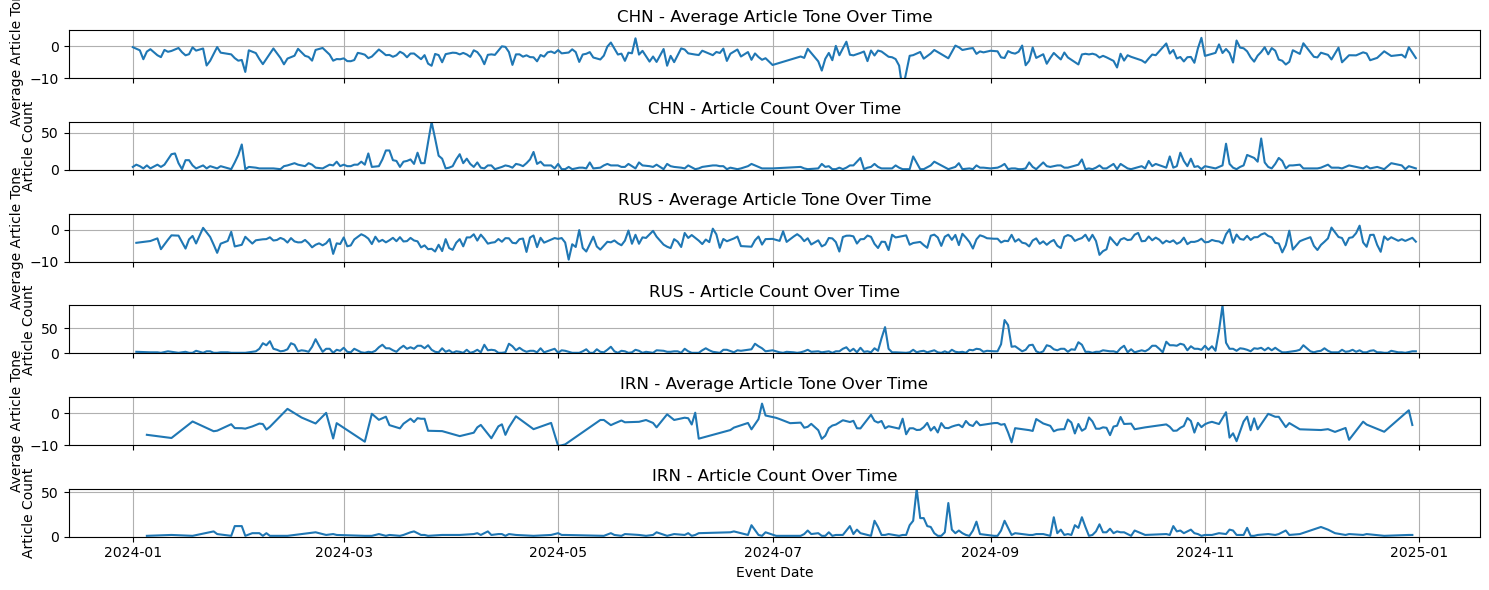

In [27]:
fig, axes = plt.subplots(6,1, figsize=(15, 6), sharex=True)
axes = axes.flatten()  # Flatten the axes array for easy indexing
for i, country in enumerate(df['Initiator_Country'].unique()):
    ax = axes[2*i]
    country_data = df[df['Initiator_Country'] == country]
    grouped = country_data.groupby('Date')['Article_Tone'].mean().reset_index()

    full_dates = pd.date_range(start=grouped['Date'].min(), end=grouped['Date'].max(), freq='D')

    ax.plot(grouped['Date'], grouped['Article_Tone'])
    ax.set_title(f"{country} - Average Article Tone Over Time")
    ax.set_ylabel('Average Article Tone')
    ax.set_ylim(-10, 5)  # Set a consistent Y-axis range for better comparison
    ax.grid(True)

    ax_2 = axes[2*i + 1]
    daily_counts = df.groupby(['Date', 'Initiator_Country'])['Date'].value_counts().reset_index(name='News')
    daily_counts = daily_counts[daily_counts['Initiator_Country'] == country].sort_values('Date')
    ax_2.plot(daily_counts['Date'], daily_counts['News'])
    ax_2.set_title(f"{country} - Article Count Over Time")
    ax_2.set_ylabel('Article Count')
    ax_2.set_ylim(0, daily_counts['News'].max())  # Set a consistent Y-axis range for better comparison
    ax_2.grid(True)

plt.xlabel('Event Date')
plt.tight_layout()

#### Initiators with different targets

In [35]:
top_targets_per_country = df[['Initiator_Country', 'Target']].groupby('Initiator_Country').value_counts()
top_targets_per_country_10 = top_targets_per_country.groupby(level=0).head(19).reset_index(name='Count')
top_targets_per_country_10

,Initiator_Country,Target,Count
0,CHN,UNITED STATES,843
1,CHN,THE US,278
2,CHN,AMERICAN,218
3,CHN,WASHINGTON,150
4,CHN,JOE BIDEN,116
5,CHN,THE WHITE HOUSE,35
6,CHN,NEW YORK,25
7,CHN,A US,24
8,CHN,SOUTH DAKOTA,23
9,CHN,SAN FRANCISCO,22


#### Democrats vs Republicans 

In [37]:
import pandas as pd

# 1. Load your downloaded data
file_name = "bq-results-20260302-194305-1772480601839.csv"  # Ensure this matches your file name
df = pd.read_csv(file_name)

# 2. Define our Party Keywords
# We use lists of keywords to catch the different ways journalists refer to the parties
democrat_keywords = ['DEMOCRAT', 'DEMOCRATIC PARTY', 'DNC']
republican_keywords = ['REPUBLICAN', 'GOP', 'REPUBLICAN PARTY', 'RNC']

# 3. Create a function to tag each article
def tag_political_party(row):
    # Combine Themes and Organizations into one giant uppercase text block to search
    # We use both just in case the AI dropped it into Themes instead of Orgs
    text_to_search = str(row['All_Organizations_Found']).upper() + " " + str(row['Themes']).upper()
    
    mentions_dem = any(keyword in text_to_search for keyword in democrat_keywords)
    mentions_rep = any(keyword in text_to_search for keyword in republican_keywords)
    
    if mentions_dem and mentions_rep:
        return 'Mentions Both'
    elif mentions_dem:
        return 'Democrat Only'
    elif mentions_rep:
        return 'Republican Only'
    else:
        return 'Neither/General'

# Apply the function to create a new column in our dataset
df['Party_Focus'] = df.apply(tag_political_party, axis=1)

# 4. Group by Country and Party Focus to see the split
party_split = df.groupby(['Initiator_Country', 'Party_Focus']).size().unstack(fill_value=0)

# Calculate the total articles per country so we can see the percentages
party_split['Total_Articles'] = party_split.sum(axis=1)

# Create a percentage version for fairer comparison
party_split_pct = party_split.copy()
for col in ['Democrat Only', 'Republican Only', 'Mentions Both', 'Neither/General']:
    if col in party_split_pct.columns:
        party_split_pct[col] = (party_split_pct[col] / party_split_pct['Total_Articles']) * 100

print("\n" + "="*60)
print(" PARTISAN FOCUS IN INTERFERENCE ARTICLES (RAW COUNT)")
print("="*60)
print(party_split[['Democrat Only', 'Republican Only', 'Mentions Both', 'Neither/General']])

print("\n" + "="*60)
print(" PARTISAN FOCUS IN INTERFERENCE ARTICLES (PERCENTAGE)")
print("="*60)
# Format the percentages to one decimal place for clean reading
print(party_split_pct[['Democrat Only', 'Republican Only', 'Mentions Both', 'Neither/General']].round(1).astype(str) + '%')


 PARTISAN FOCUS IN INTERFERENCE ARTICLES (RAW COUNT)
Party_Focus        Democrat Only  Republican Only  Mentions Both  \
Initiator_Country                                                  
CHN                          298              362            465   
IRN                          135              227            227   
RUS                          372              652            737   

Party_Focus        Neither/General  
Initiator_Country                   
CHN                           1433  
IRN                            693  
RUS                           1376  

 PARTISAN FOCUS IN INTERFERENCE ARTICLES (PERCENTAGE)
Party_Focus       Democrat Only Republican Only Mentions Both Neither/General
Initiator_Country                                                            
CHN                       11.6%           14.2%         18.2%           56.0%
IRN                       10.5%           17.7%         17.7%           54.1%
RUS                       11.9%           20.8%      

In [62]:
democrat_only

,index,count
0,2024-01-01,5
1,2024-01-02,3
2,2024-01-03,5
3,2024-01-04,1
4,2024-01-05,2
...,...,...
361,2024-12-27,0
362,2024-12-28,0
363,2024-12-29,0
364,2024-12-30,0


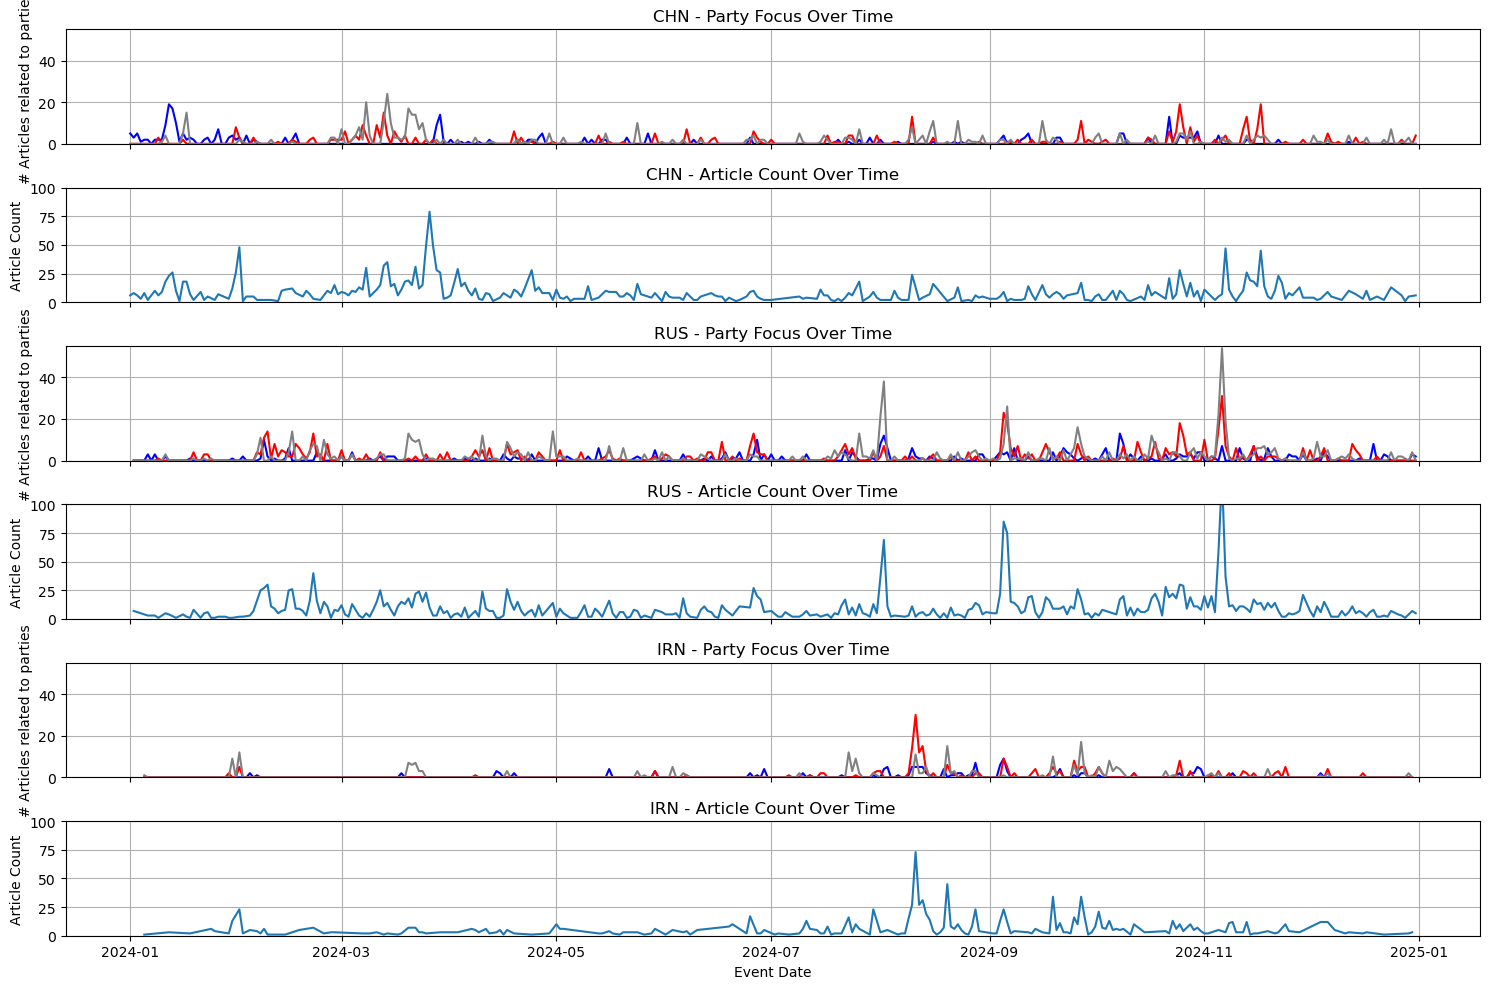

In [71]:
# Show Party Focus along 3 countries and 4 categories (Dem Only, Rep Only, Both, Neither) temporally

fig, axes = plt.subplots(6,1, figsize=(15, 10), sharex=True)
axes = axes.flatten()  # Flatten the axes array for easy indexing
for i, country in enumerate(df['Initiator_Country'].unique()):
    ax = axes[2*i]
    country_data = df[df['Initiator_Country'] == country]

    full_dates = pd.date_range(start=country_data['Event_Date'].min(), end=country_data['Event_Date'].max(), freq='D')

    democrat_only = country_data[country_data['Party_Focus'] == 'Democrat Only'].groupby('Event_Date')["Event_Date"].value_counts().reset_index()
    democrat_only = democrat_only.set_index('Event_Date').reindex(full_dates, fill_value=0).reset_index()
    ax.plot(democrat_only['index'], democrat_only['count'], label='Democrat Only', color = 'blue')

    republican_only = country_data[country_data['Party_Focus'] == 'Republican Only'].groupby('Event_Date')["Event_Date"].value_counts().reset_index()
    republican_only = republican_only.set_index('Event_Date').reindex(full_dates, fill_value=0).reset_index()
    ax.plot(republican_only['index'], republican_only['count'], label='Republican Only', color = 'red')

    both = country_data[country_data['Party_Focus'] == 'Mentions Both'].groupby('Event_Date')["Event_Date"].value_counts().reset_index()
    both = both.set_index('Event_Date').reindex(full_dates, fill_value=0).reset_index()
    ax.plot(both['index'], both['count'], label='Mentions Both', color = 'gray')

    ax.set_title(f"{country} - Party Focus Over Time")
    ax.set_ylabel('# Articles related to parties')
    ax.set_ylim(0,55)
    ax.grid(True)



    ax_2 = axes[2*i + 1]
    daily_counts = df.groupby(['Event_Date', 'Initiator_Country'])['Event_Date'].value_counts().reset_index(name='News')
    daily_counts = daily_counts[daily_counts['Initiator_Country'] == country].sort_values('Event_Date')
    ax_2.plot(daily_counts['Event_Date'], daily_counts['News'])
    ax_2.set_title(f"{country} - Article Count Over Time")
    ax_2.set_ylabel('Article Count')
    ax_2.set_ylim(0, 100)  # Set a consistent Y-axis range for better comparison
    ax_2.grid(True)

plt.xlabel('Event Date')
plt.tight_layout()